In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Skipping, found downloaded files in "./animal-faces" (use force=True to force download)


In [ ]:
import torch
# Main PyTorch library → used for tensors, GPU support, deep learning ops

from torch import nn
# Neural Network module → used to build layers (Linear, Conv, etc.)

from torch.optim import Adam
# Adam optimizer → used to update model weights during training

from torchvision.transforms import transforms
# Image preprocessing tools → resize, normalize, convert to tensor

from torch.utils.data import Dataset, DataLoader
# Dataset → custom data class
# DataLoader → loads data in batches, shuffles, etc.

from sklearn.preprocessing import LabelEncoder
# Converts labels (like "basmati", "jasmine") into numeric values (0,1,2...)

import matplotlib.pyplot as plt
# Used for plotting graphs (loss, accuracy, images)

from PIL import Image
# Used to open and process images

import pandas as pd
# Used to read CSV files and handle tabular data

import numpy as np
# Used for numerical operations and arrays

import os
# Used for file paths and directory operations


device = "cuda" if torch.cuda.is_available() else "cpu"
# Check if GPU is available → use "cuda" if yes, else use CPU

print("Device available: ", device)
# Print which device (CPU/GPU) is being used

Device available:  cpu


In [ ]:
image_path = []
# List to store full paths of images

labels = []
# List to store corresponding labels (folder names)


# Loop through main directory (e.g., train/val/test or animal types)
for i in os.listdir("/content/animal-faces/afhq"):

    # Loop through label folders inside each main folder (e.g., cat, dog, wild)
    for label in os.listdir(f"/content/animal-faces/afhq/{i}"):

        # Loop through images inside each label folder
        for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):

            # Append full image path to list
            image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")

            # Append corresponding label (folder name)
            labels.append(label)


# Create a DataFrame combining image paths and labels
data_df = pd.DataFrame(
    zip(image_path, labels),  # Combine both lists
    columns=["image_path", "labels"]  # Column names
)

# Display first 5 rows of DataFrame
data_df.head()

,image_path,labels
0,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
1,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
2,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog
3,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog
4,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog


In [ ]:
# Split dataset into training set (70% of total data)
train = data_df.sample(frac=0.7)

# Remaining 30% goes into temporary test set
test = data_df.drop(train.index)


# From the remaining data, take 50% for validation
# (i.e., 15% of total data)
val = test.sample(frac=0.5)

# Remaining 50% becomes final test set (15% of total data)
test = test.drop(val.index)


# Print shapes of datasets (rows, columns)
print(train.shape)  # Training data size
print(val.shape)    # Validation data size
print(test.shape)   # Test data size

(11291, 2)
(2420, 2)
(2419, 2)


In [ ]:
# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder on label column (e.g., cat, dog → 0, 1)
label_encoder.fit(data_df["labels"])


# Define image transformations
transform = transforms.Compose([

    transforms.Resize((128, 128)),
    # Resize all images to 128x128 (required for uniform input size)

    transforms.ToTensor(),
    # Convert image to PyTorch tensor (also scales pixel values to [0,1])

    transforms.ConvertImageDtype(torch.float)
    # Ensure tensor is in float format (needed for model training)
])

In [ ]:
# Custom Dataset class for loading images and labels
class CustomImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        # Store the dataframe containing image paths and labels

        self.transform = transform
        # Store transformation pipeline (resize, tensor, etc.)

        # Convert string labels (cat, dog, etc.) → numeric labels (0,1,2...)
        # Then convert to PyTorch tensor and move to device (CPU/GPU)
        self.labels = torch.tensor(
            label_encoder.transform(dataframe['labels'])
        ).to(device)


    def __len__(self):
        # Return total number of samples in dataset
        return self.dataframe.shape[0]


    def __getitem__(self, idx):
        # Get image path from dataframe (column 0 = image_path)
        img_path = self.dataframe.iloc[idx, 0]

        # Get corresponding label
        label = self.labels[idx]

        # Open image and convert to RGB format
        image = Image.open(img_path).convert('RGB')

        # Apply transformations if provided
        if self.transform:
            image = self.transform(image).to(device)

        # Return image tensor and label
        return image, label

In [ ]:
# Create training dataset using training dataframe
train_dataset = CustomImageDataset(
    dataframe=train,        # Training data (70%)
    transform=transform     # Apply image transformations
)

# Create validation dataset using validation dataframe
val_dataset = CustomImageDataset(
    dataframe=val,          # Validation data (15%)
    transform=transform     # Same transformations applied
)

# Create test dataset using test dataframe
test_dataset = CustomImageDataset(
    dataframe=test,         # Test data (15%)
    transform=transform     # Same transformations applied
)

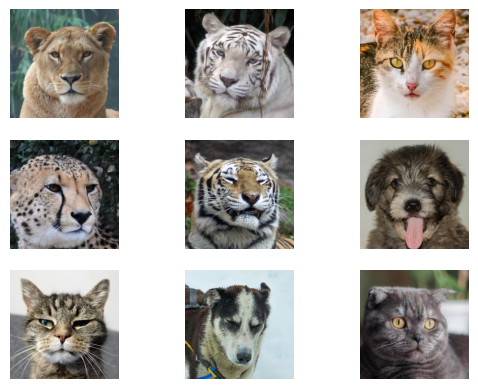

In [ ]:
# Number of rows and columns for plotting grid
n_rows = 3
n_cols = 3

# Create a grid of subplots (3x3)
f, axarr = plt.subplots(n_rows, n_cols)

# Loop through each cell in the grid
for row in range(n_rows):
    for col in range(n_cols):

        # Randomly select 1 image path from dataframe
        img_path = data_df.sample(n=1)["image_path"].iloc[0]

        # Open image and convert to RGB format
        image = Image.open(img_path).convert("RGB")

        # Display image in subplot
        axarr[row, col].imshow(image)

        # Remove axis (ticks, labels)
        axarr[row, col].axis('off')

# Show the full grid of images
plt.show()

In [ ]:
# =========================
# HYPERPARAMETERS
# =========================

LR = 1e-4
# Learning Rate → controls how fast model learns (small = stable, slow)

BATCH_SIZE = 16
# Number of samples processed in one batch

EPOCHS = 10
# Number of times the model sees the full dataset

In [ ]:
# =========================
# DATALOADERS
# =========================

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,   # Load 16 samples at a time
    shuffle=True             # Shuffle data for better learning
)

# Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,   # Same batch size
    shuffle=True             # Shuffle (optional, not strictly needed)
)

# Test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,   # Same batch size
    shuffle=True             # Usually False, but True is okay for now
)

In [ ]:
# Define CNN model
class Net(nn.Module):

    def __init__(self):
        super().__init__()

        # =========================
        # CONVOLUTION LAYERS
        # =========================
        # padding=1 keeps height and width same after convolution
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)


        # =========================
        # POOLING & ACTIVATION
        # =========================

        self.pooling = nn.MaxPool2d(2, 2)
        # Reduces spatial size by half (downsampling)

        self.relu = nn.ReLU()
        # Activation function → adds non-linearity


        # =========================
        # FULLY CONNECTED LAYERS
        # =========================

        self.flatten = nn.Flatten()
        # Converts 3D feature map → 1D vector

        self.linear = nn.Linear(128 * 16 * 16, 128)
        # Input features after conv layers → 128 neurons

        # Output layer → number of classes
        self.output = nn.Linear(
            128,
            len(data_df['labels'].unique())  # Number of classes
        )


    def forward(self, x):

        # =========================
        # LAYER 1
        # =========================
        x = self.conv1(x)       # → (32, 128, 128)
        x = self.pooling(x)     # → (32, 64, 64)
        x = self.relu(x)


        # =========================
        # LAYER 2
        # =========================
        x = self.conv2(x)       # → (64, 64, 64)
        x = self.pooling(x)     # → (64, 32, 32)
        x = self.relu(x)


        # =========================
        # LAYER 3
        # =========================
        x = self.conv3(x)       # → (128, 32, 32)
        x = self.pooling(x)     # → (128, 16, 16)
        x = self.relu(x)


        # =========================
        # FULLY CONNECTED
        # =========================
        x = self.flatten(x)     # → (128 * 16 * 16)
        x = self.linear(x)      # → (128)
        x = self.output(x)      # → (num_classes)

        return x

In [ ]:
model=Net().to(device)

In [ ]:
from torchsummary import summary
# Import summary tool → used to visualize model architecture

summary(model, input_size=(3, 128, 128))
# Print model summary
# input_size = (channels, height, width)
# Here: 3 = RGB channels, 128x128 = image size

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [ ]:
criterion = nn.CrossEntropyLoss()
# Loss function for multi-class classification
# It compares predicted outputs with true labels

optimizer = Adam(model.parameters(), lr=LR)
# Adam optimizer → updates model weights during training
# model.parameters() → all learnable parameters of the model
# lr = LR → learning rate (how fast model learns)

In [ ]:
# Lists to store metrics for plotting
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

# Loop over epochs
for epoch in range(EPOCHS):

    # Initialize metrics for each epoch
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    # =========================
    # TRAINING LOOP
    # =========================
    model.train()  # Set model to training mode

    for inputs, labels in train_loader:

        optimizer.zero_grad()  # Clear previous gradients

        outputs = model(inputs)  # Forward pass
        train_loss = criterion(outputs, labels)  # Compute loss

        total_loss_train += train_loss.item()  # Accumulate loss

        train_loss.backward()  # Backpropagation

        # Calculate training accuracy (correct predictions)
        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc

        optimizer.step()  # Update weights


    # =========================
    # VALIDATION LOOP
    # =========================
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient computation
        for inputs, labels in val_loader:

            outputs = model(inputs)  # Forward pass
            val_loss = criterion(outputs, labels)  # Compute loss

            total_loss_val += val_loss.item()  # Accumulate validation loss

            # Calculate validation accuracy
            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc


    # =========================
    # STORE METRICS
    # =========================

    total_loss_train_plot.append(round(total_loss_train / 1000, 4))
    # Store average training loss (scaled)

    total_loss_validation_plot.append(round(total_loss_val / 1000, 4))
    # Store average validation loss (scaled)

    total_acc_train_plot.append(
        round((total_acc_train / train_dataset.__len__()) * 100, 4)
    )
    # Training accuracy in %

    total_acc_validation_plot.append(
        round((total_acc_val / val_dataset.__len__()) * 100, 4)
    )
    # Validation accuracy in %


    # =========================
    # PRINT METRICS
    # =========================
    print(
        f"Epoch {epoch+1}/{EPOCHS}, "
        f"Train Loss: {round(total_loss_train/1000, 4)}, "
        f"Train Accuracy: {round((total_acc_train/train_dataset.__len__()) * 100, 4)}, "
        f"Validation Loss: {round(total_loss_val/1000, 4)}, "
        f"Validation Accuracy: {round((total_acc_val/val_dataset.__len__()) * 100, 4)}"
    )

In [ ]:
# =========================
# TEST LOOP (FINAL EVALUATION)
# =========================

model.eval()  # Set model to evaluation mode

with torch.no_grad():  # Disable gradient computation (faster + memory efficient)

    total_loss_test = 0
    # To store total test loss

    total_acc_test = 0
    # To store total correct predictions

    for inputs, labels in test_loader:

        predictions = model(inputs)
        # Forward pass → get predictions

        # Calculate accuracy (count correct predictions)
        acc = (torch.argmax(predictions, axis=1) == labels).sum().item()
        total_acc_test += acc

        # Calculate loss
        test_loss = criterion(predictions, labels)
        total_loss_test += test_loss.item()


# =========================
# PRINT FINAL RESULTS
# =========================

print(
    f"Accuracy Score is: {round((total_acc_test / test_dataset.__len__()) * 100, 4)} "
    f"and Loss is {round(total_loss_test / 1000, 4)}"
)

In [ ]:
# Create a figure with 1 row and 2 columns (side-by-side plots)
fig, axs = plt.subplots(n_rows=1, n_cols=2, figsize=(15, 5))


# =========================
# LOSS PLOT
# =========================

axs[0].plot(total_loss_train_plot, label='Training Loss')
# Plot training loss over epochs

axs[0].plot(total_loss_validation_plot, label='Validation Loss')
# Plot validation loss over epochs

axs[0].set_title('Training and Validation Loss over Epochs')
# Title of the loss graph

axs[0].set_xlabel('Epochs')
# X-axis label

axs[0].set_ylabel('Loss')
# Y-axis label

axs[0].legend()
# Show legend (Training vs Validation)


# =========================
# ACCURACY PLOT
# =========================

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
# Plot training accuracy over epochs

axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
# Plot validation accuracy over epochs

axs[1].set_title('Training and Validation Accuracy over Epochs')
# Title of the accuracy graph

axs[1].set_xlabel('Epochs')
# X-axis label

axs[1].set_ylabel('Accuracy')
# Y-axis label

axs[1].legend()
# Show legend


# =========================
# DISPLAY PLOTS
# =========================

plt.show()
# Render the plots